In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ottdata.csv to ottdata.csv


In [3]:
df = pd.read_csv('ottdata.csv')
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


In [4]:
print("Shape of the dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape of the dataset: (1000, 8)

Data Types:
 visitors              float64
ad_impressions        float64
major_sports_event      int64
genre                  object
dayofweek              object
season                 object
views_trailer         float64
views_content         float64
dtype: object

Missing Values:
 visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64


In [5]:
df.describe()

,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1.704290,1434.712290,0.400000,66.91559,0.473400
std,0.231973,289.534834,0.490143,35.00108,0.105914
min,1.250000,1010.870000,0.000000,30.08000,0.220000
25%,1.550000,1210.330000,0.000000,50.94750,0.400000
50%,1.700000,1383.580000,0.000000,53.96000,0.450000
75%,1.830000,1623.670000,1.000000,57.75500,0.520000
max,2.340000,2424.200000,1.000000,199.92000,0.890000


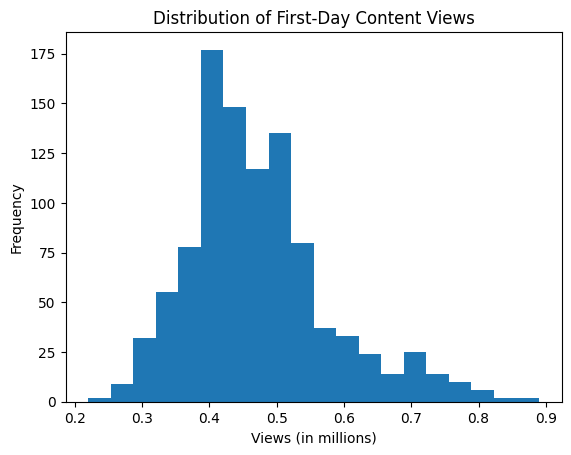

In [6]:
plt.hist(df['views_content'], bins=20)
plt.title('Distribution of First-Day Content Views')
plt.xlabel('Views (in millions)')
plt.ylabel('Frequency')
plt.show()

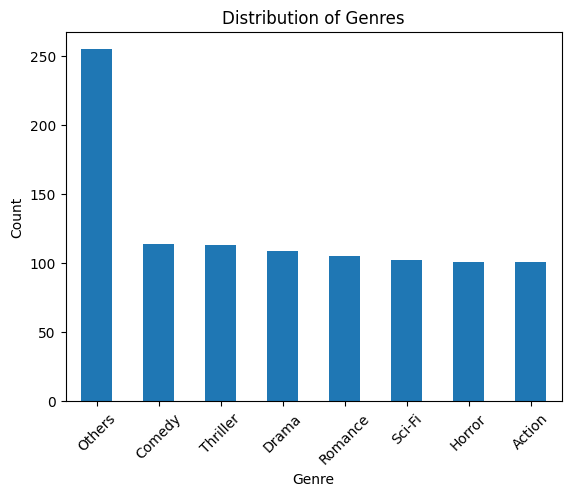

In [7]:
df['genre'].value_counts().plot(kind='bar')
plt.title('Distribution of Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

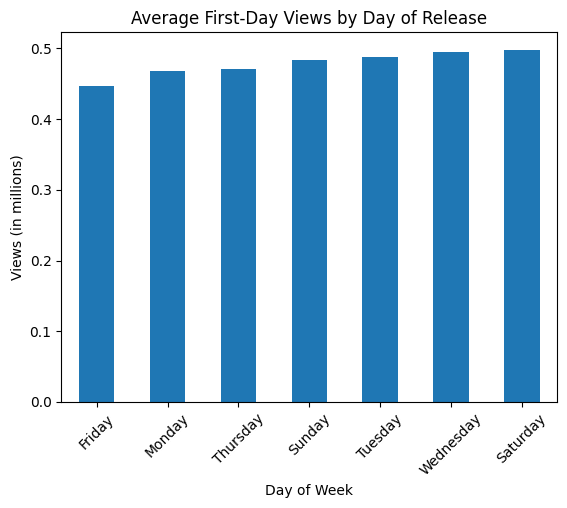

In [8]:
df.groupby('dayofweek')['views_content'].mean().sort_values().plot(kind='bar')
plt.title('Average First-Day Views by Day of Release')
plt.ylabel('Views (in millions)')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.show()

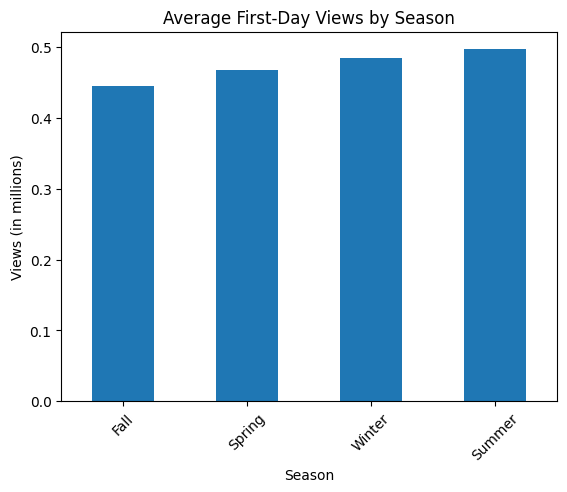

In [10]:
df.groupby('season')['views_content'].mean().sort_values().plot(kind='bar')
plt.title('Average First-Day Views by Season')
plt.ylabel('Views (in millions)')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.show()

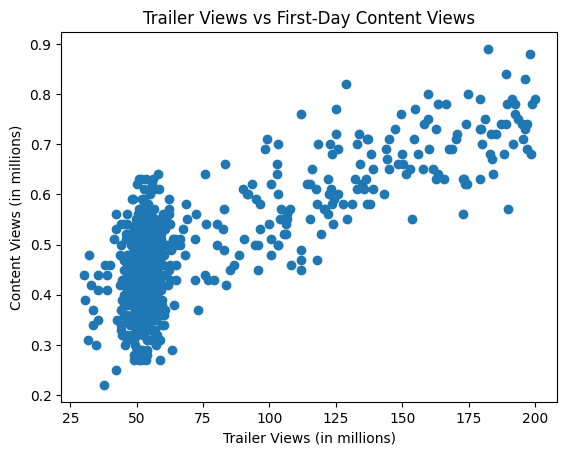

Correlation between trailer views and content views: 0.753962214820536


In [11]:
plt.scatter(df['views_trailer'], df['views_content'])
plt.title('Trailer Views vs First-Day Content Views')
plt.xlabel('Trailer Views (in millions)')
plt.ylabel('Content Views (in millions)')
plt.show()

correlation = df['views_trailer'].corr(df['views_content'])
print("Correlation between trailer views and content views:", correlation)

In [12]:
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


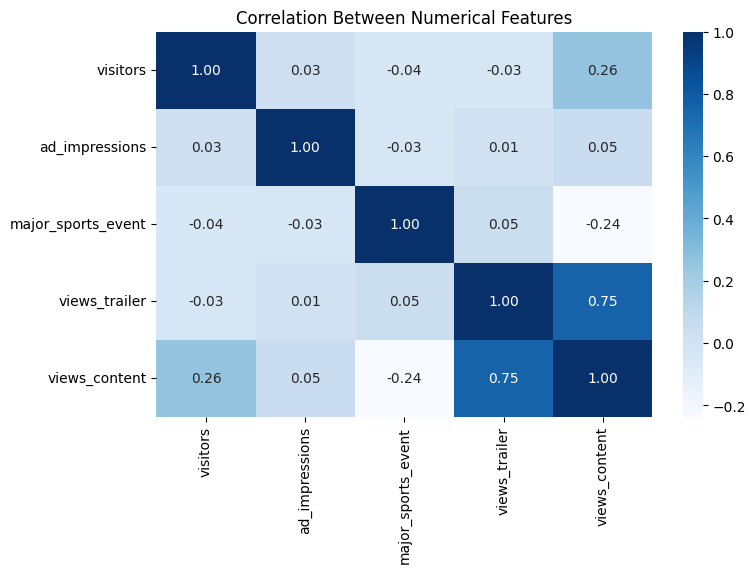

In [19]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Between Numerical Features')
plt.show()


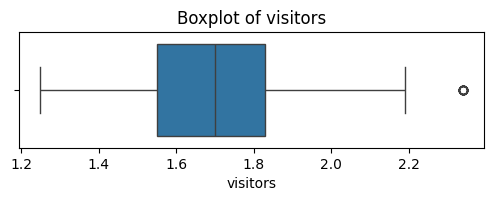

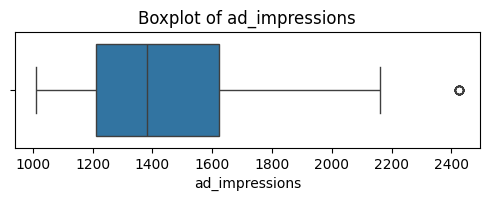

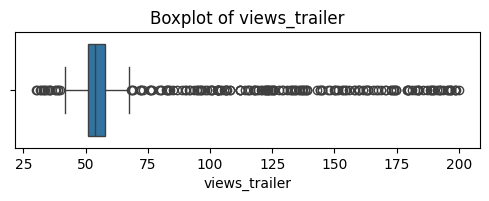

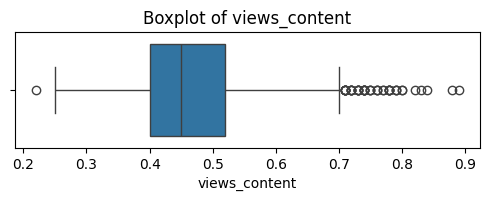

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

for col in num_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [22]:
print("Duplicate rows before removal:", df.duplicated().sum())

Duplicate rows before removal: 0


In [23]:
df_encoded = pd.get_dummies(df, columns=['genre', 'dayofweek', 'season'], drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (1000, 21)


,visitors,ad_impressions,major_sports_event,views_trailer,views_content,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.67,1113.81,0,56.70,0.51,False,False,True,False,False,...,False,False,False,False,False,False,True,True,False,False
1,1.46,1498.41,1,52.69,0.32,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,1.47,1079.19,1,48.74,0.39,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,1.85,1342.77,1,49.81,0.44,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.46,1498.41,0,55.83,0.46,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [26]:
X = df_encoded.drop(columns=['views_content'])
y = df_encoded['views_content']

print("Final shape of X:", X.shape)
print("Final shape of y:", y.shape)

Final shape of X: (1000, 20)
Final shape of y: (1000,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (800, 20)
Testing set size: (200, 20)


In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [31]:
print("Intercept:", lr.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})
print(coef_df.sort_values(by='Coefficient', ascending=False))

Intercept: 0.054787293096868694
                Feature  Coefficient
0              visitors     0.128909
12   dayofweek_Saturday     0.052561
16  dayofweek_Wednesday     0.049532
11     dayofweek_Monday     0.045065
18        season_Summer     0.044605
13     dayofweek_Sunday     0.038818
15    dayofweek_Tuesday     0.032412
19        season_Winter     0.026532
17        season_Spring     0.023201
14   dayofweek_Thursday     0.019637
10       genre_Thriller     0.011518
5           genre_Drama     0.010636
9          genre_Sci-Fi     0.010008
6          genre_Horror     0.009434
7          genre_Others     0.004984
4          genre_Comedy     0.004389
3         views_trailer     0.002311
1        ad_impressions     0.000008
8         genre_Romance    -0.001385
2    major_sports_event    -0.059559


In [32]:
r2_train = lr.score(X_train, y_train)
print("R-squared (training set):", r2_train)

R-squared (training set): 0.7868365918498103


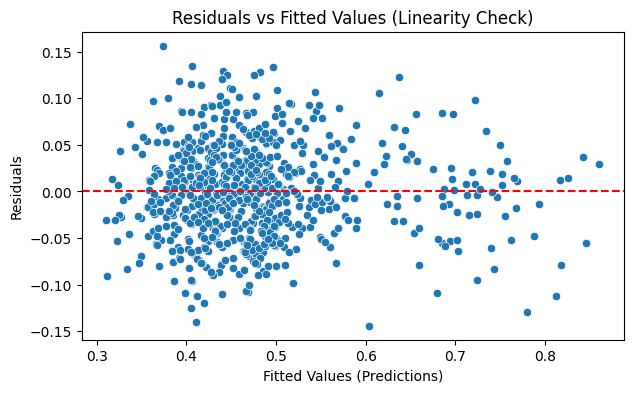

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_pred = lr.predict(X_train)

residuals = y_train - y_train_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=y_train_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Predictions)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Linearity Check)")
plt.show()

In [35]:
X = X.astype(int)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False))

                Feature        VIF
1        ad_impressions  15.180256
0              visitors  10.521414
3         views_trailer   4.358402
7          genre_Others   2.960980
19        season_Winter   2.044921
18        season_Summer   1.966443
17        season_Spring   1.936544
4          genre_Comedy   1.905067
10       genre_Thriller   1.894294
5           genre_Drama   1.890737
9          genre_Sci-Fi   1.877466
16  dayofweek_Wednesday   1.875649
8         genre_Romance   1.814690
6          genre_Horror   1.789937
2    major_sports_event   1.707364
14   dayofweek_Thursday   1.255447
12   dayofweek_Saturday   1.242962
13     dayofweek_Sunday   1.190984
15    dayofweek_Tuesday   1.074365
11     dayofweek_Monday   1.071910


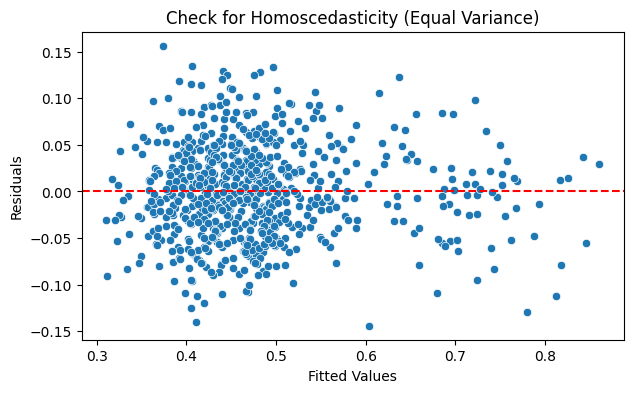

In [36]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x=y_train_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Check for Homoscedasticity (Equal Variance)")
plt.show()

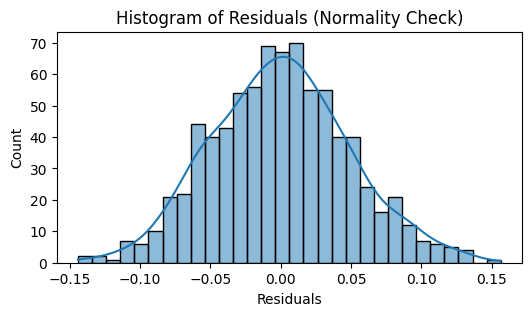

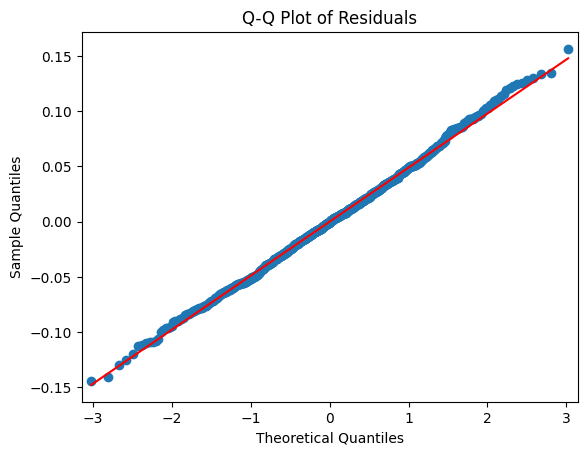

In [37]:
import scipy.stats as stats

plt.figure(figsize=(6, 3))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Histogram of Residuals (Normality Check)")
plt.xlabel("Residuals")
plt.show()

import statsmodels.api as sm
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_test_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_test_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (Test Set): {r2_test:.4f}")

Mean Absolute Error (MAE): 0.0399
Mean Squared Error (MSE): 0.0025
Root Mean Squared Error (RMSE): 0.0500
R-squared (Test Set): 0.7743
